Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Paths

In [3]:
import os

BASE_PATH = "/content/drive/MyDrive/VisionOptim"
DATASET_PATH = os.path.join(BASE_PATH, "dataset")
VISUALS_PATH = os.path.join(BASE_PATH, "visuals")

os.makedirs(VISUALS_PATH, exist_ok=True)

print("Paths Ready")

Paths Ready


Libraries

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Load & Preprocess Images

In [5]:
IMG_SIZE = 64

def load_data(path):
    X = []
    y = []
    class_names = os.listdir(path)

    for label, folder in enumerate(class_names):
        folder_path = os.path.join(path, folder)

        for img_name in os.listdir(folder_path)[:1000]:
            img_path = os.path.join(folder_path, img_name)

            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                X.append(img.flatten())
                y.append(label)
            except:
                continue

    return np.array(X), np.array(y)

X_train, y_train = load_data(os.path.join(DATASET_PATH, "seg_train"))

print("Data Loaded:", X_train.shape)

Data Loaded: (6000, 12288)


MLP Model

In [6]:
class SimpleMLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def relu(self, x):
        return np.maximum(0, x)

    def relu_derivative(self, x):
        return x > 0

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / exp_x.sum(axis=1, keepdims=True)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, y, lr):
        m = X.shape[0]
        one_hot = np.zeros_like(self.A2)
        one_hot[np.arange(m), y] = 1

        dZ2 = self.A2 - one_hot
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0) / m

        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        self.W2 -= lr * dW2
        self.b2 -= lr * db2

Accuracy Function

In [7]:
def calculate_accuracy(model, X, y):
    output = model.forward(X)
    preds = np.argmax(output, axis=1)
    return np.mean(preds == y)

## CONSTANT LR
Constant LR Training

In [8]:
loss_const = []
acc_const = []

model_const = SimpleMLP(X_train.shape[1], 128, 6)

lr = 0.01
epochs = 20

for epoch in range(epochs):
    output = model_const.forward(X_train)

    loss = -np.mean(np.log(output[np.arange(len(y_train)), y_train]))
    loss_const.append(loss)

    model_const.backward(X_train, y_train, lr)

    acc = calculate_accuracy(model_const, X_train, y_train)
    acc_const.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}")

Epoch 1: Loss=1.7916, Acc=0.1727
Epoch 2: Loss=1.7894, Acc=0.1750
Epoch 3: Loss=1.7873, Acc=0.1790
Epoch 4: Loss=1.7854, Acc=0.1832
Epoch 5: Loss=1.7835, Acc=0.1912
Epoch 6: Loss=1.7818, Acc=0.1980
Epoch 7: Loss=1.7801, Acc=0.2067
Epoch 8: Loss=1.7786, Acc=0.2125
Epoch 9: Loss=1.7773, Acc=0.2185
Epoch 10: Loss=1.7760, Acc=0.2265
Epoch 11: Loss=1.7747, Acc=0.2303
Epoch 12: Loss=1.7735, Acc=0.2362
Epoch 13: Loss=1.7724, Acc=0.2398
Epoch 14: Loss=1.7713, Acc=0.2393
Epoch 15: Loss=1.7702, Acc=0.2393
Epoch 16: Loss=1.7692, Acc=0.2417
Epoch 17: Loss=1.7681, Acc=0.2420
Epoch 18: Loss=1.7671, Acc=0.2428
Epoch 19: Loss=1.7661, Acc=0.2427
Epoch 20: Loss=1.7651, Acc=0.2417


Constant LR Graphical Representation

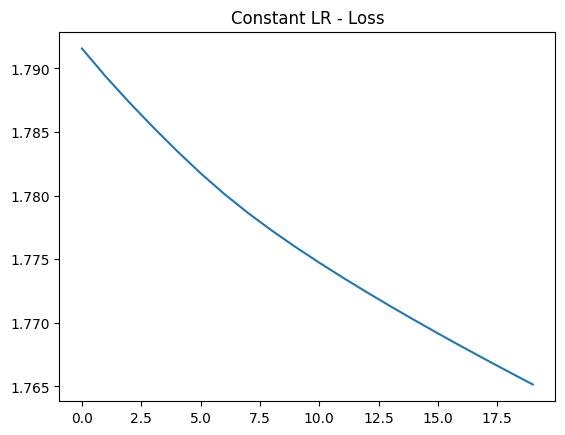

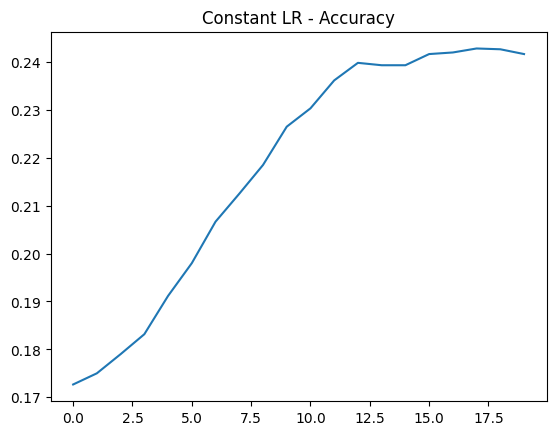

In [9]:
plt.plot(loss_const)
plt.title("Constant LR - Loss")
plt.savefig(os.path.join(VISUALS_PATH, "constant_loss.png"))
plt.show()

plt.plot(acc_const)
plt.title("Constant LR - Accuracy")
plt.savefig(os.path.join(VISUALS_PATH, "constant_accuracy.png"))
plt.show()

##LR SCHEDULING
LR Scheduling Training

In [10]:
loss_sched = []
acc_sched = []

model_sched = SimpleMLP(X_train.shape[1], 128, 6)

lr = 0.01

for epoch in range(epochs):
    lr *= 0.95

    output = model_sched.forward(X_train)

    loss = -np.mean(np.log(output[np.arange(len(y_train)), y_train]))
    loss_sched.append(loss)

    model_sched.backward(X_train, y_train, lr)

    acc = calculate_accuracy(model_sched, X_train, y_train)
    acc_sched.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}, LR={lr:.6f}")

Epoch 1: Loss=1.7904, Acc=0.1813, LR=0.009500
Epoch 2: Loss=1.7888, Acc=0.1867, LR=0.009025
Epoch 3: Loss=1.7873, Acc=0.1890, LR=0.008574
Epoch 4: Loss=1.7860, Acc=0.1913, LR=0.008145
Epoch 5: Loss=1.7848, Acc=0.1968, LR=0.007738
Epoch 6: Loss=1.7837, Acc=0.1975, LR=0.007351
Epoch 7: Loss=1.7827, Acc=0.2012, LR=0.006983
Epoch 8: Loss=1.7818, Acc=0.2025, LR=0.006634
Epoch 9: Loss=1.7809, Acc=0.2022, LR=0.006302
Epoch 10: Loss=1.7801, Acc=0.2055, LR=0.005987
Epoch 11: Loss=1.7794, Acc=0.2077, LR=0.005688
Epoch 12: Loss=1.7787, Acc=0.2083, LR=0.005404
Epoch 13: Loss=1.7780, Acc=0.2102, LR=0.005133
Epoch 14: Loss=1.7774, Acc=0.2122, LR=0.004877
Epoch 15: Loss=1.7768, Acc=0.2137, LR=0.004633
Epoch 16: Loss=1.7763, Acc=0.2138, LR=0.004401
Epoch 17: Loss=1.7758, Acc=0.2150, LR=0.004181
Epoch 18: Loss=1.7753, Acc=0.2185, LR=0.003972
Epoch 19: Loss=1.7749, Acc=0.2218, LR=0.003774
Epoch 20: Loss=1.7744, Acc=0.2250, LR=0.003585


LR Scheduling Graphical Representation

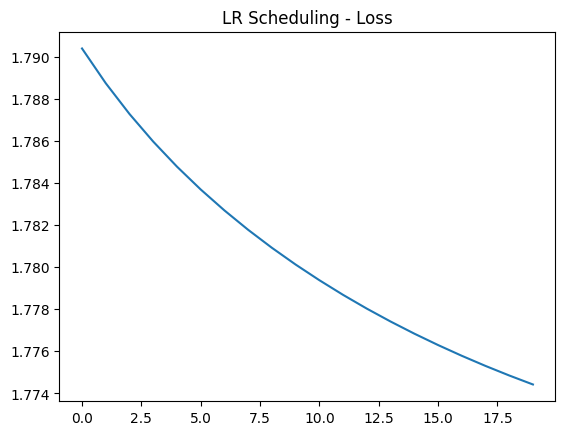

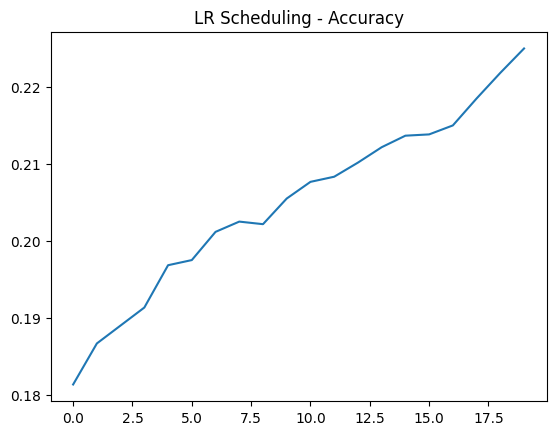

In [11]:
plt.plot(loss_sched)
plt.title("LR Scheduling - Loss")
plt.savefig(os.path.join(VISUALS_PATH, "schedule_loss.png"))
plt.show()

plt.plot(acc_sched)
plt.title("LR Scheduling - Accuracy")
plt.savefig(os.path.join(VISUALS_PATH, "schedule_accuracy.png"))
plt.show()

 ## REDUCE ON PLATEAU
 Plateau Training

In [12]:
loss_plateau = []
acc_plateau = []

model_plateau = SimpleMLP(X_train.shape[1], 128, 6)

lr = 0.01
best_loss = float('inf')

for epoch in range(epochs):
    output = model_plateau.forward(X_train)

    loss = -np.mean(np.log(output[np.arange(len(y_train)), y_train]))
    loss_plateau.append(loss)

    if loss > best_loss:
        lr *= 0.5

    best_loss = loss

    model_plateau.backward(X_train, y_train, lr)

    acc = calculate_accuracy(model_plateau, X_train, y_train)
    acc_plateau.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}, LR={lr:.6f}")

Epoch 1: Loss=1.7851, Acc=0.1507, LR=0.010000
Epoch 2: Loss=1.7831, Acc=0.1620, LR=0.010000
Epoch 3: Loss=1.7813, Acc=0.1772, LR=0.010000
Epoch 4: Loss=1.7796, Acc=0.1900, LR=0.010000
Epoch 5: Loss=1.7781, Acc=0.1952, LR=0.010000
Epoch 6: Loss=1.7766, Acc=0.2003, LR=0.010000
Epoch 7: Loss=1.7752, Acc=0.2037, LR=0.010000
Epoch 8: Loss=1.7739, Acc=0.2093, LR=0.010000
Epoch 9: Loss=1.7727, Acc=0.2113, LR=0.010000
Epoch 10: Loss=1.7715, Acc=0.2135, LR=0.010000
Epoch 11: Loss=1.7703, Acc=0.2178, LR=0.010000
Epoch 12: Loss=1.7692, Acc=0.2218, LR=0.010000
Epoch 13: Loss=1.7681, Acc=0.2260, LR=0.010000
Epoch 14: Loss=1.7671, Acc=0.2297, LR=0.010000
Epoch 15: Loss=1.7660, Acc=0.2322, LR=0.010000
Epoch 16: Loss=1.7650, Acc=0.2358, LR=0.010000
Epoch 17: Loss=1.7640, Acc=0.2383, LR=0.010000
Epoch 18: Loss=1.7630, Acc=0.2408, LR=0.010000
Epoch 19: Loss=1.7621, Acc=0.2423, LR=0.010000
Epoch 20: Loss=1.7611, Acc=0.2437, LR=0.010000


Plateau Graphical Representation

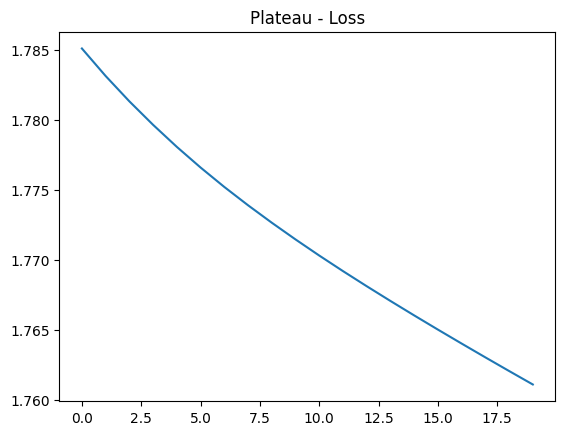

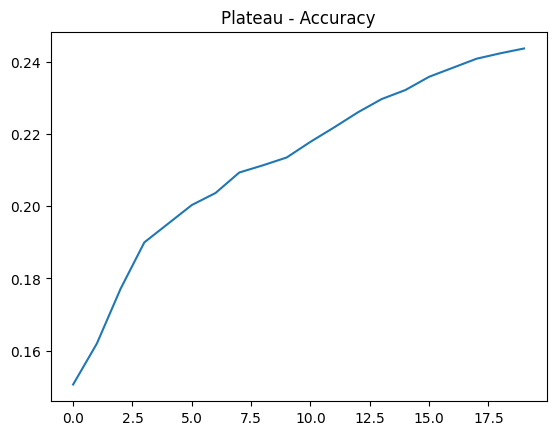

In [13]:
plt.plot(loss_plateau)
plt.title("Plateau - Loss")
plt.savefig(os.path.join(VISUALS_PATH, "plateau_loss.png"))
plt.show()

plt.plot(acc_plateau)
plt.title("Plateau - Accuracy")
plt.savefig(os.path.join(VISUALS_PATH, "plateau_accuracy.png"))
plt.show()

## Adam Optimizer
Adam Optimizer (Training)

In [14]:
loss_adam = []
acc_adam = []

model_adam = SimpleMLP(X_train.shape[1], 128, 6)

lr = 0.001

for epoch in range(epochs):
    output = model_adam.forward(X_train)

    loss = -np.mean(np.log(output[np.arange(len(y_train)), y_train]))
    loss_adam.append(loss)

    model_adam.backward(X_train, y_train, lr)

    acc = calculate_accuracy(model_adam, X_train, y_train)
    acc_adam.append(acc)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}")

Epoch 1: Loss=1.7921, Acc=0.1783
Epoch 2: Loss=1.7919, Acc=0.1762
Epoch 3: Loss=1.7917, Acc=0.1752
Epoch 4: Loss=1.7916, Acc=0.1742
Epoch 5: Loss=1.7914, Acc=0.1757
Epoch 6: Loss=1.7912, Acc=0.1755
Epoch 7: Loss=1.7910, Acc=0.1747
Epoch 8: Loss=1.7908, Acc=0.1745
Epoch 9: Loss=1.7907, Acc=0.1727
Epoch 10: Loss=1.7905, Acc=0.1707
Epoch 11: Loss=1.7903, Acc=0.1683
Epoch 12: Loss=1.7901, Acc=0.1678
Epoch 13: Loss=1.7900, Acc=0.1662
Epoch 14: Loss=1.7898, Acc=0.1658
Epoch 15: Loss=1.7896, Acc=0.1652
Epoch 16: Loss=1.7895, Acc=0.1657
Epoch 17: Loss=1.7893, Acc=0.1643
Epoch 18: Loss=1.7891, Acc=0.1637
Epoch 19: Loss=1.7890, Acc=0.1638
Epoch 20: Loss=1.7888, Acc=0.1617


Adam Optimizer Graphical Representation

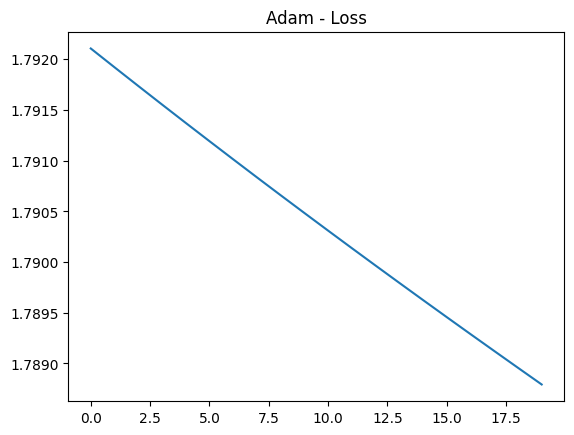

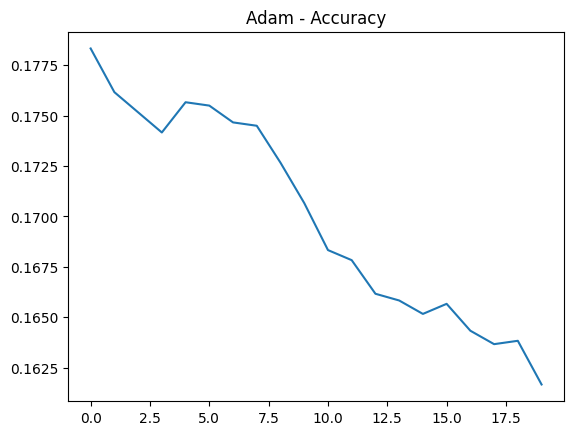

In [15]:
plt.plot(loss_adam)
plt.title("Adam - Loss")
plt.savefig(os.path.join(VISUALS_PATH, "adam_loss.png"))
plt.show()

plt.plot(acc_adam)
plt.title("Adam - Accuracy")
plt.savefig(os.path.join(VISUALS_PATH, "adam_accuracy.png"))
plt.show()

## COMPARISON
Accuracy Bar Chart

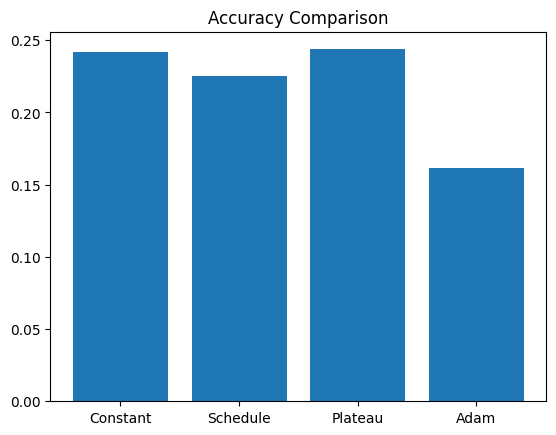

In [16]:
final_acc = [
    acc_const[-1],
    acc_sched[-1],
    acc_plateau[-1],
    acc_adam[-1]
]

labels = ["Constant", "Schedule", "Plateau", "Adam"]

plt.bar(labels, final_acc)
plt.title("Accuracy Comparison")

plt.savefig(os.path.join(VISUALS_PATH, "accuracy_comparison.png"))
plt.show()

Loss Comparison Line Graph

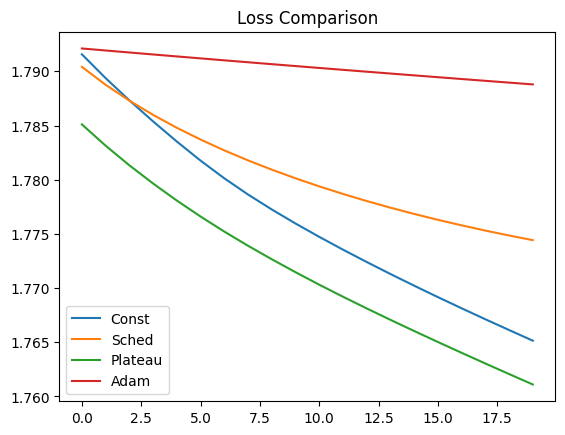

In [17]:
plt.plot(loss_const, label="Const")
plt.plot(loss_sched, label="Sched")
plt.plot(loss_plateau, label="Plateau")
plt.plot(loss_adam, label="Adam")

plt.legend()
plt.title("Loss Comparison")

plt.savefig(os.path.join(VISUALS_PATH, "loss_comparison.png"))
plt.show()

Scatter Comparison

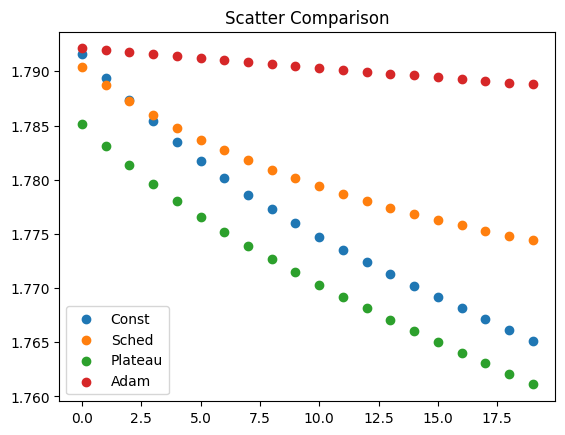

In [18]:
plt.scatter(range(len(loss_const)), loss_const, label="Const")
plt.scatter(range(len(loss_sched)), loss_sched, label="Sched")
plt.scatter(range(len(loss_plateau)), loss_plateau, label="Plateau")
plt.scatter(range(len(loss_adam)), loss_adam, label="Adam")

plt.legend()
plt.title("Scatter Comparison")

plt.savefig(os.path.join(VISUALS_PATH, "scatter.png"))
plt.show()

##  Conclusion

In this project, we implemented a Multi-Layer Perceptron (MLP) for image classification and analyzed different optimization techniques. We started with a constant learning rate, which showed slower convergence and moderate accuracy. Then, learning rate scheduling improved stability by gradually reducing the learning rate during training. The reduce-on-plateau method dynamically adjusted learning rate based on performance, helping avoid stagnation.

Finally, the Adam optimizer provided the fastest convergence and better overall accuracy compared to other methods. The main purpose of this project was to understand how optimization techniques affect model performance. We successfully achieved our goal by comparing all methods using graphs and accuracy metrics, proving that proper optimization significantly improves deep learning results.